# 01 — The `Leaf`, in pictures

Hands-on companion to [`docs/01-leaf.md`](../docs/01-leaf.md).

> Run this with the notebook extra installed: `pip install -e ".[notebooks]"`

In [1]:
import matplotlib.pyplot as plt

from bonsaigrad import Leaf

## A drawing helper

This walks a graph through its own `_prev` / `_op` fields — the same structure
`bend` uses — and lays nodes out by depth: roots at the bottom, the output at
the top. Each box shows the op, its `data`, and its `grad`; a node turns green
once a gradient has reached it.

With `edge_labels=True` each arrow is annotated with its **local derivative**
(`∂child/∂parent`): `1` for a `+` edge, the *other* operand for a `*` edge.
Multiply the gradient in a node by an outgoing edge label and you get the
contribution that flows to the parent — the chain rule, drawn.

In [2]:
def _trace(root):
    nodes, edges, seen = [], [], set()

    def walk(n):
        if id(n) in seen:
            return
        seen.add(id(n))
        nodes.append(n)
        for p in n._prev:
            edges.append((p, n))
            walk(p)

    walk(root)
    return nodes, edges


def _depth(node, memo):
    if id(node) in memo:
        return memo[id(node)]
    d = 0 if not node._prev else 1 + max(_depth(p, memo) for p in node._prev)
    memo[id(node)] = d
    return d


def _local_deriv(child, parent):
    if child._op == "+":
        return 1.0
    if child._op == "*":
        other = child._prev[0] if child._prev[1] is parent else child._prev[1]
        return other.data.item()
    return None


def draw_graph(root, names=None, ax=None, title=None, edge_labels=False):
    names = names or {}
    nodes, edges = _trace(root)

    memo, levels = {}, {}
    for n in nodes:
        levels.setdefault(_depth(n, memo), []).append(n)

    pos = {}
    for d, layer in levels.items():
        for i, n in enumerate(layer):
            pos[id(n)] = (i - (len(layer) - 1) / 2, d)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    for p, ch in edges:
        (x0, y0), (x1, y1) = pos[id(p)], pos[id(ch)]
        ax.annotate("", xy=(x1, y1 - 0.30), xytext=(x0, y0 + 0.30),
                    arrowprops=dict(arrowstyle="-|>", color="#8a8a8a", lw=1.4))
        if edge_labels:
            loc = _local_deriv(ch, p)
            if loc is not None:
                ax.text((x0 + x1) / 2, (y0 + y1) / 2, f"x{loc:.4g}",
                        fontsize=8, color="#b03030", ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    for n in nodes:
        x, y = pos[id(n)]
        label = names.get(id(n)) or (n._op if n._op else "leaf")
        flowed = float(n.grad) != 0.0
        color = "#cde8d1" if flowed else "#e8e8e8"
        ax.text(x, y, f"{label}\ndata {n.data.item():.4g}\ngrad {n.grad.item():.4g}",
                ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="#4a4a4a", lw=1.2))

    xs = [p[0] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.9, max(xs) + 0.9)
    ax.set_ylim(-0.6, max(levels) + 0.6)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)
    return ax

## An expression grows a graph

Writing `f = a * b + a` does not just compute a number — every `*` and `+` creates a new `Leaf` that remembers its parents. Build it one operation at a time and watch the tree grow:

```
g = a * b        # step 1
f = g + a        # step 2
```

Notice `a` is used **twice** — once inside the product, once on its own. It shows up as a single node with two arrows leaving it.

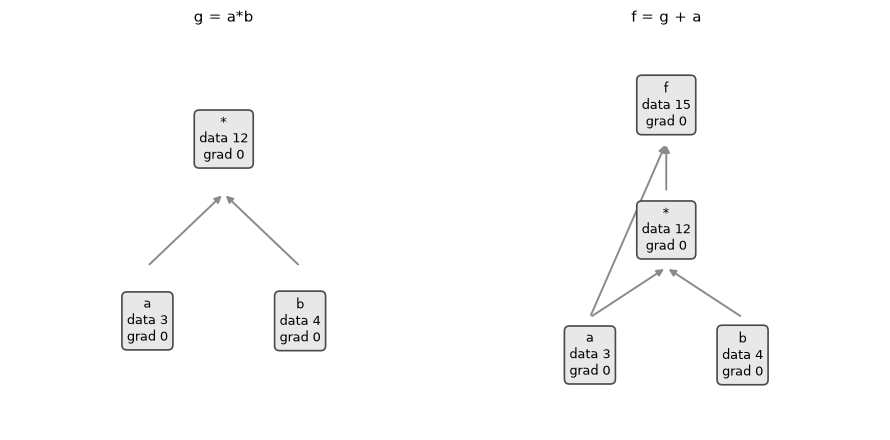

In [3]:
a = Leaf(3.0)
b = Leaf(4.0)

g = a * b
f = g + a

names = {id(a): "a", id(b): "b", id(f): "f"}

steps = [(g, "g = a*b"), (f, "f = g + a")]
fig, axes = plt.subplots(1, len(steps), figsize=(9, 4.5))
for ax, (root, label) in zip(axes, steps):
    draw_graph(root, names, ax=ax, title=label)
plt.tight_layout()
plt.show()

## The backward pass, one level at a time

`bend` seeds the top with `1` and walks the tree in reverse. Here we freeze it after each level to watch the gradient cascade — a box turns green once its gradient is known.

Keep your eye on `a`. It receives gradient **twice**: first straight from `f` (step 1, `a.grad = 1`), then again through the product `g` (step 2, `+= b = 4`). The two paths add up to `a.grad = 5` — that is the `+=` in the backward rules, made visible.

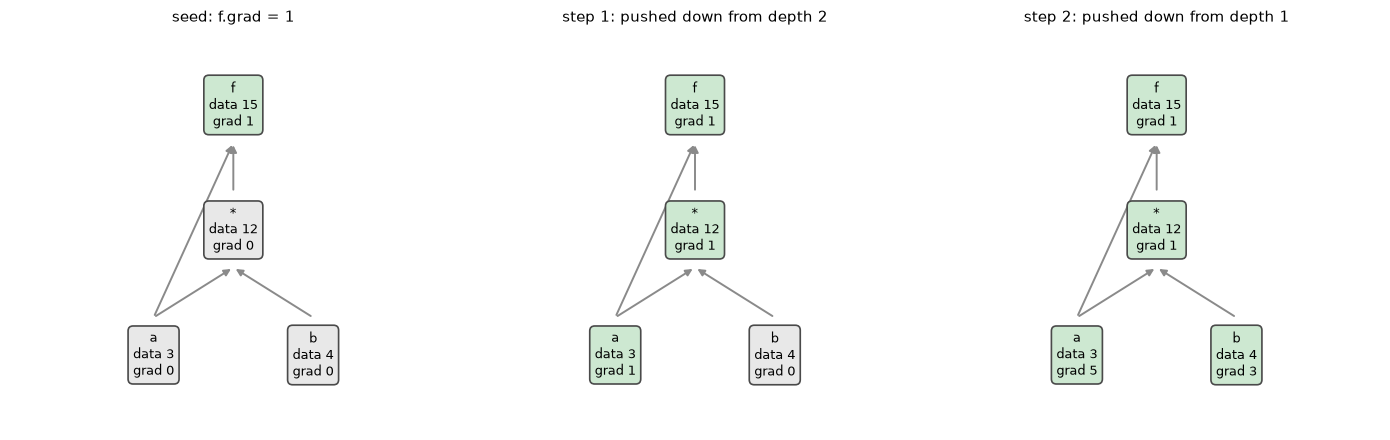

a.grad = 5.0 (expected 5.0)
b.grad = 3.0 (expected 3.0)


In [4]:
import numpy as np

nodes, _ = _trace(f)
memo, levels = {}, {}
for n in nodes:
    levels.setdefault(_depth(n, memo), []).append(n)

for n in nodes:  # clean slate
    n.grad = np.zeros_like(n.data)
f.grad = np.ones_like(f.data)  # seed the output

depths = sorted(levels, reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
draw_graph(f, names, ax=axes[0], title="seed: f.grad = 1")
for k, depth in enumerate(depths[:-1], start=1):  # leaves have no parents
    for node in levels[depth]:
        node._backward()
    draw_graph(f, names, ax=axes[k], title=f"step {k}: pushed down from depth {depth}")
plt.tight_layout()
plt.show()

print("a.grad =", a.grad.item(), "(expected 5.0)")
print("b.grad =", b.grad.item(), "(expected 3.0)")
assert a.grad.item() == 5.0 and b.grad.item() == 3.0

## A tiny neuron

The same machinery already gives us a single neuron: `y = w * x + b`. Weight `w`,
input `x`, bias `b`. Below, the graph before and after `bend`, side by side.

By hand, `∂y/∂w = x`, `∂y/∂x = w`, `∂y/∂b = 1` — read them straight off the green
boxes on the right.

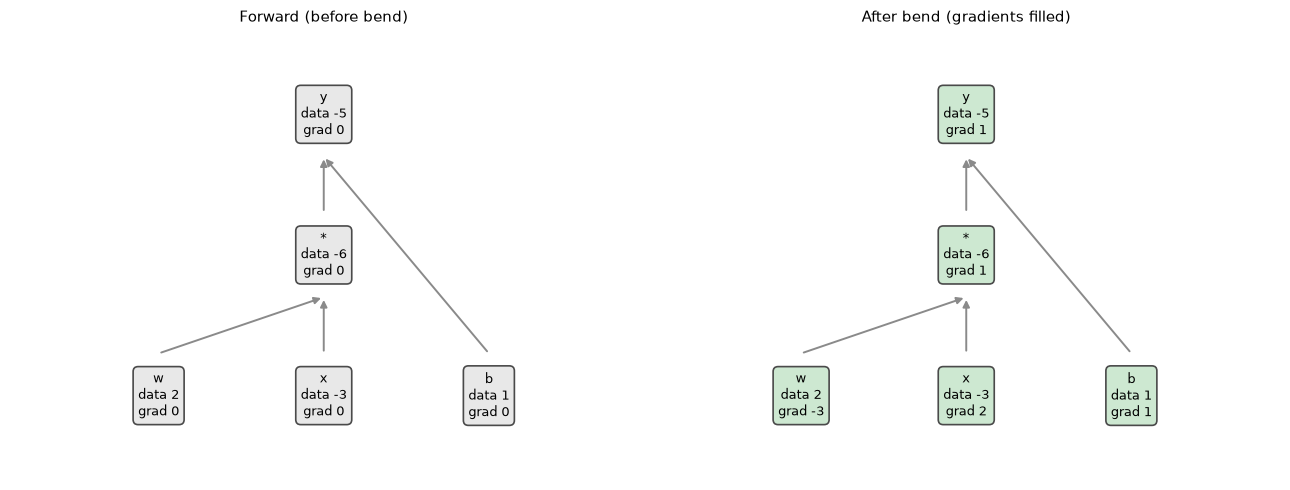

y = -5.0  |  w.grad = -3.0  x.grad = 2.0  b.grad = 1.0


In [5]:
w, x, b = Leaf(2.0), Leaf(-3.0), Leaf(1.0)
y = w * x + b
names = {id(w): "w", id(x): "x", id(b): "b", id(y): "y"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
draw_graph(y, names, ax=ax1, title="Forward (before bend)")
y.bend()
draw_graph(y, names, ax=ax2, title="After bend (gradients filled)")
plt.tight_layout()
plt.show()

print(f"y = {y.data.item()}  |  w.grad = {w.grad.item()}  x.grad = {x.grad.item()}  b.grad = {b.grad.item()}")

## The example

`L = (a + b) * (b + c)` — two sums feeding one product. `b` is used **twice**, so it shows up as a single node with two arrows leaving it, one into each sum.

Below, the graph after the forward pass and again after `bend`. Each edge is labelled (in red) with its **local derivative** `∂child/∂parent`: `1` for a `+` edge, the *other* operand for a `*` edge. A node's gradient times an outgoing edge label is what flows to the parent — the chain rule, drawn. Because `b` feeds both sums, it collects gradient from both paths: `7 + 5 = 12`.

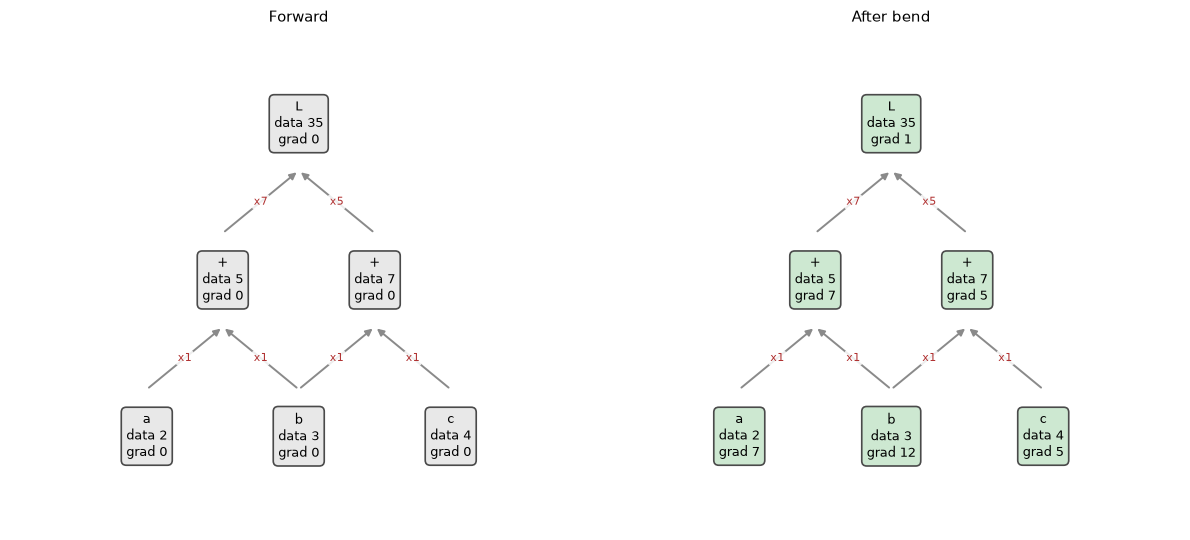

L = 35.0
a.grad = 7
b.grad = 12
c.grad = 5


In [6]:
a, b, c = Leaf(2.0), Leaf(3.0), Leaf(4.0)
L = (a + b) * (b + c)

names = {id(a): "a", id(b): "b", id(c): "c", id(L): "L"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
draw_graph(L, names, ax=ax1, title="Forward", edge_labels=True)
L.bend()
draw_graph(L, names, ax=ax2, title="After bend", edge_labels=True)
plt.tight_layout()
plt.show()

print("L =", L.data.item())
for name, leaf in zip("abc", (a, b, c)):
    print(f"{name}.grad = {leaf.grad.item():.0f}")